# Bab 4 — Regression and Prediction
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. Simple linear regression
2. Multiple linear regression
3. Menilai model: RMSE, R², t-statistic
4. Cross-validation
5. Pemilihan model & stepwise regression
6. Weighted regression
7. Prediksi dengan regresi (confidence vs prediction interval)
8. Variabel faktor (kategorikal) dalam regresi
9. Menafsirkan persamaan regresi (multikolinearitas, confounding, interaksi)
10. Diagnostik regresi (outlier, influential values, heteroskedastisitas, partial residual plot)
11. Regresi polinomial, spline, dan GAM


In [1]:
!pip install statsmodels pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.9 MB/s eta 0:00:00


In [2]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy.interpolate import splrep
import seaborn as sns
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## Gambaran Besar

Pertanyaan yang paling sering muncul dalam statistik: *apakah variabel X berhubungan dengan variabel Y, dan jika ya, bagaimana bentuk hubungannya? Bisakah X dipakai untuk memprediksi Y?*

Hubungan antara prediksi dan penjelasan paling kuat terlihat di **regresi linear**, yang punya dua kegunaan besar:
- **Explanation (profiling)** — memahami hubungan antar variabel.
- **Prediction** — memprediksi nilai outcome untuk data baru.

## 1. Simple Linear Regression

**Istilah kunci:**
- **Response** — variabel yang ingin diprediksi (sinonim: dependent variable, Y, target, outcome).
- **Independent variable** — variabel untuk memprediksi (sinonim: X, feature, attribute, predictor).
- **Record** — satu baris data (sinonim: row, case, instance, example).
- **Intercept** ($b_0$) — nilai prediksi ketika X = 0.
- **Regression coefficient** ($b_1$) — kemiringan garis (slope).
- **Fitted values** ($\hat{Y}_i$) — nilai prediksi dari model.
- **Residuals** ($e_i$) — selisih nilai aktual dan fitted.
- **Least squares** — metode mencari garis dengan meminimalkan jumlah kuadrat residual.

Korelasi (Bab 1) mengukur **kekuatan** hubungan dua variabel. Regresi melangkah lebih jauh: ia **mengkuantifikasi bentuk** hubungan itu.

### Persamaan regresi
$$Y = b_0 + b_1 X$$

### Contoh: Paparan debu kapas vs kapasitas paru
Data dari buku: `PEFR` (*peak expiratory flow rate*, ukuran fungsi paru) dan `Exposure` (lama paparan debu kapas dalam tahun) pada pekerja pabrik tekstil. Apakah paparan yang lebih lama berkaitan dengan fungsi paru yang lebih buruk?

(122, 2)


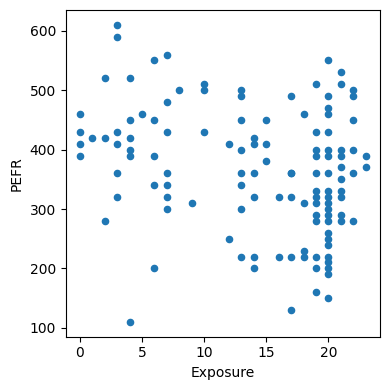

In [3]:
lung = pd.read_csv(DATA + 'LungDisease.csv')
print(lung.shape)
lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
plt.tight_layout(); plt.show()

In [4]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


Persamaan hasil fitting: **PEFR = 424,583 − 4,185 × Exposure**.

Interpretasi:
- Pekerja tanpa paparan (0 tahun) diperkirakan punya PEFR sekitar **424,6**.
- Setiap tambahan **1 tahun paparan**, PEFR diperkirakan **turun sekitar 4,185**.

### Fitted Values dan Residuals
Dalam praktik data tidak jatuh persis di garis. Maka persamaan lengkapnya memasukkan error:
$$Y_i = b_0 + b_1 X_i + e_i$$
Nilai fitted (prediksi) diberi topi:
$$\hat{Y}_i = \hat{b}_0 + \hat{b}_1 X_i$$
Residual = nilai aktual − nilai prediksi:
$$\hat{e}_i = Y_i - \hat{Y}_i$$

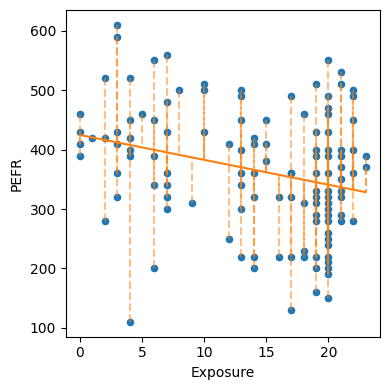

In [5]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted, color='C1')
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted):
    ax.plot((x, x), (yactual, yfitted), '--', color='C1', alpha=0.5)
plt.tight_layout(); plt.show()

Garis putus-putus vertikal adalah **residual**: jarak antara titik data dan garis regresi.

### Least Squares
Garis regresi dipilih dengan meminimalkan **residual sum of squares (RSS)**:
$$RSS = \sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2 = \sum_{i=1}^{n}(Y_i - \hat{b}_0 - \hat{b}_1 X_i)^2$$

Rumus langsungnya:
$$\hat{b}_1 = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2}, \qquad \hat{b}_0 = \bar{Y} - \hat{b}_1 \bar{X}$$

Metode ini disebut **ordinary least squares (OLS)**. Kelemahannya: seperti mean, OLS **sensitif terhadap outlier**. Tapi karena mudah dihitung, ia menjadi standar.

In [6]:
# Cek rumus least squares secara manual
X, Y = lung['Exposure'], lung['PEFR']
b1 = ((X - X.mean()) * (Y - Y.mean())).sum() / ((X - X.mean()) ** 2).sum()
b0 = Y.mean() - b1 * X.mean()
print(f'Manual -> b0 = {b0:.3f}, b1 = {b1:.3f}')

Manual -> b0 = 424.583, b1 = -4.185


### Prediction vs Explanation (Profiling)
- **Explanation**: dipakai untuk memahami hubungan (misalnya "apakah paparan debu memengaruhi paru-paru?"). Fokus pada **koefisien** dan interpretasinya.
- **Prediction**: dipakai untuk memprediksi outcome data baru (misalnya harga rumah). Fokus pada **akurasi prediksi**.

**Peringatan:** regresi sendiri **tidak membuktikan hubungan sebab-akibat**. Kesimpulan kausal harus berasal dari pemahaman yang lebih luas tentang hubungan tersebut (atau dari eksperimen yang dirancang dengan baik).

## 2. Multiple Linear Regression

Jika ada lebih dari satu prediktor:
$$Y = b_0 + b_1 X_1 + b_2 X_2 + \dots + b_p X_p + e$$

Bukan lagi garis, melainkan **model linear** (bidang/hyperplane). Konsep least squares, fitted values, dan residual tetap sama.

**Istilah kunci:**
- **Root mean squared error (RMSE)** — akar dari rata-rata kuadrat error; ukuran akurasi yang paling umum.
- **Residual standard error (RSE)** — mirip RMSE, tapi disesuaikan dengan degrees of freedom.
- **R-squared ($R^2$)** — proporsi variansi yang dijelaskan model (0 sampai 1).
- **t-statistic** — koefisien dibagi standard error-nya; untuk membandingkan pentingnya variabel.
- **Weighted regression** — regresi dengan bobot berbeda untuk tiap record.

### Contoh: Harga Rumah di King County
Data penjualan rumah di King County (Seattle, Washington). Tujuan: memprediksi harga jual (disesuaikan inflasi, `AdjSalePrice`) dari karakteristik rumah.

In [7]:
house = pd.read_csv(DATA + 'house_sales.csv', sep='\t')
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
print(house.shape)
house[subset].head()

(22687, 22)


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [8]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef:.3f}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.831
 SqFtLot: -0.060
 Bathrooms: -19442.840
 Bedrooms: -47769.955
 BldgGrade: 106106.963


Interpretasi koefisien pada multiple regression: **perubahan harga untuk setiap kenaikan 1 unit prediktor, dengan prediktor lain dianggap tetap**. Contoh: menambah 1 sq ft luas bangunan (dengan variabel lain sama) diperkirakan menaikkan harga sekitar **$229**, jadi 1.000 sq ft ≈ $229.000.

Perhatikan: koefisien `Bedrooms` **negatif**. Ini tampak aneh, dan akan dibahas di bagian 9 (prediktor yang saling berkorelasi).

## 3. Menilai Model

### RMSE dan RSE
$$RMSE = \sqrt{\frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{n}}$$
$$RSE = \sqrt{\frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{n - p - 1}}$$
$p$ = jumlah prediktor. Untuk data besar, RMSE ≈ RSE.

### R-squared (coefficient of determination)
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
Menyatakan proporsi variasi data yang dijelaskan model. Berguna terutama untuk tujuan **penjelasan**.

In [9]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2  : {r2:.4f}')

RMSE: 261220
r2  : 0.5406


Model menjelaskan sekitar **54%** variasi harga rumah, dengan RMSE sekitar **$261.000**.

### Output Lengkap dengan statsmodels
`statsmodels` memberi tabel lengkap: koefisien, **standard error (SE)**, **t-statistic**, dan **p-value**.
$$t_b = \frac{\hat{b}}{SE(\hat{b})}$$
Semakin besar |t| (dan semakin kecil p-value), semakin kuat bukti bahwa prediktor itu berguna. Di data science, t-statistic dan p-value biasanya dipakai sebagai **panduan** memilih variabel, bukan sebagai uji hipotesis formal.

In [10]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        01:09:11   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

## 4. Cross-Validation

Metrik seperti R² dan t-statistic adalah metrik **in-sample**: dihitung dari data yang sama dengan data untuk membangun model. Model bisa terlalu menyesuaikan diri dengan data tersebut (**overfitting**).

Idealnya kita menguji model pada data **baru** (**holdout sample**). Tapi satu holdout saja bisa kebetulan beruntung/sial. **Cross-validation** mengulangi ide holdout beberapa kali.

**Algoritma k-fold cross-validation:**
1. Sisihkan 1/k data sebagai holdout.
2. Latih model pada sisa data.
3. Terapkan model ke holdout, catat metrik performanya.
4. Kembalikan holdout, sisihkan 1/k data berikutnya (yang belum pernah jadi holdout).
5. Ulangi sampai setiap record pernah menjadi holdout satu kali.
6. Rata-ratakan (atau gabungkan) metrik dari semua fold.

Setiap pembagian disebut **fold**.

In [11]:
scores = cross_val_score(LinearRegression(), house[predictors], house[outcome],
                         cv=5, scoring='neg_root_mean_squared_error')
print('RMSE per fold:', (-scores).round(0))
print(f'Rata-rata RMSE (5-fold CV): {-scores.mean():.0f}')

r2_scores = cross_val_score(LinearRegression(), house[predictors], house[outcome], cv=5, scoring='r2')
print('R² per fold  :', r2_scores.round(3))

RMSE per fold: [243016. 269290. 293158. 278565. 217994.]
Rata-rata RMSE (5-fold CV): 260405
R² per fold  : [0.589 0.548 0.527 0.48  0.554]


## 5. Pemilihan Model dan Stepwise Regression

Menambah variabel ke model tidak selalu lebih baik. Prinsip **Occam's razor**: di antara model yang sama baiknya, pilih yang **paling sederhana**.

Menambah variabel selalu menurunkan RMSE in-sample dan menaikkan R², meskipun variabelnya tidak berguna. Maka kita butuh metrik yang **menghukum kompleksitas**:

- **Adjusted R²**
$$R^2_{adj} = 1 - (1 - R^2)\frac{n-1}{n-P-1}$$
- **AIC (Akaike's Information Criterion)** — semakin kecil semakin baik:
$$AIC = 2P + n \log(RSS/n)$$
$P$ = jumlah variabel, $n$ = jumlah record. Setiap tambahan variabel menambah "penalti" 2.

Variasi AIC:
- **AICc** — versi AIC untuk sampel kecil.
- **BIC** — penalti lebih besar untuk variabel tambahan.
- **Mallows Cp** — varian yang dikembangkan Colin Mallows.

### Cara mencari model terbaik
- **All subset regression** — coba semua kombinasi. Mahal secara komputasi untuk banyak variabel.
- **Stepwise regression** — tambah/buang variabel satu per satu:
  - **Forward selection** — mulai dari kosong, tambah prediktor yang paling memperbaiki model.
  - **Backward elimination** — mulai dari model penuh, buang prediktor yang tidak signifikan.
  - **Stepwise** — kombinasi keduanya.
- **Penalized regression** (Ridge, Lasso) — alternatif modern; koefisien "dikecilkan" secara otomatis, tidak dibuang secara diskrit.

Contoh: model dengan lebih banyak prediktor, lalu dipilih dengan stepwise berbasis AIC.

In [12]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
              'PropertyType', 'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt',
              'YrRenovated', 'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
y = house[outcome]

house_full = sm.OLS(y, X.assign(const=1)).fit()
print(house_full.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving                198.6364      4.234     46.920      0.000     190.338     206.934
SqFtLot                        0.0771      0.058      1.330      0.184      -0.037       0.191
Bathrooms                   4.286e+04   3808.114     11.255      0.000    3.54e+04    5.03e+04
Bedrooms                   -5.187e+04   2396.904    -21.638      0.000   -5.66e+04   -4.72e+04
BldgGrade                   1.373e+05   2441.242     56.228      0.000    1.32e+05    1.42e+05
NbrLivingUnits              5723.8438   1.76e+04      0.326      0.744   -2.87e+04    4.01e+04
SqFtFinBasement                7.0611      4.627      1.526      0.127      -2.009      16.131
YrBuilt                    -3574.2210     77.228    -46.282      0.000   -3725.593   -3422.849
YrRenovated                   -2.5311      3.924  

In [13]:
# Stepwise (forward + backward) berbasis AIC — implementasi sederhana
def aic_of(cols):
    Xc = X[cols].assign(const=1) if cols else pd.DataFrame({'const': np.ones(len(X))}, index=X.index)
    return sm.OLS(y, Xc).fit().aic

def stepwise_aic(candidates, verbose=True):
    selected, best_aic = [], aic_of([])
    while True:
        changed = False
        # forward step
        adds = [(aic_of(selected + [c]), c) for c in candidates if c not in selected]
        if adds:
            aic, c = min(adds)
            if aic < best_aic:
                selected.append(c); best_aic = aic; changed = True
                if verbose: print(f'+ {c:30s} AIC = {aic:,.0f}')
        # backward step
        if len(selected) > 1:
            drops = [(aic_of([s for s in selected if s != c]), c) for c in selected]
            aic, c = min(drops)
            if aic < best_aic:
                selected.remove(c); best_aic = aic; changed = True
                if verbose: print(f'- {c:30s} AIC = {aic:,.0f}')
        if not changed:
            return selected

best_variables = stepwise_aic(list(X.columns))

+ SqFtTotLiving                  AIC = 633,011
+ BldgGrade                      AIC = 630,792
+ YrBuilt                        AIC = 628,228
+ Bedrooms                       AIC = 627,782
+ Bathrooms                      AIC = 627,600
+ PropertyType_Townhouse         AIC = 627,524
+ SqFtFinBasement                AIC = 627,523
+ PropertyType_Single Family     AIC = 627,523


In [14]:
best_model = sm.OLS(y, X[best_variables].assign(const=1)).fit()
print(f'Variabel terpilih ({len(best_variables)}):', best_variables)
print(best_model.params.round(3))

Variabel terpilih (8): ['SqFtTotLiving', 'BldgGrade', 'YrBuilt', 'Bedrooms', 'Bathrooms', 'PropertyType_Townhouse', 'SqFtFinBasement', 'PropertyType_Single Family']
SqFtTotLiving                     199.278
BldgGrade                      137159.560
YrBuilt                         -3565.425
Bedrooms                       -51947.384
Bathrooms                       42396.165
PropertyType_Townhouse          84479.162
SqFtFinBasement                     7.047
PropertyType_Single Family      22912.055
const                         6178645.017
dtype: float64


Stepwise membuang beberapa variabel (misalnya `SqFtLot`, `NbrLivingUnits`, `YrRenovated`, `NewConstruction`) yang tidak cukup memperbaiki AIC.

**Hati-hati:** stepwise dan all-subset regression adalah metode **in-sample**, sehingga rentan overfitting. Model terpilih perlu divalidasi di data baru (cross-validation). Model yang sangat kompleks cenderung terlihat bagus di data latih tapi buruk di data baru.

## 6. Weighted Regression

**Weighted regression** memberi bobot berbeda pada tiap record saat fitting. Berguna ketika:
- **Inverse-variance weighting** — pengamatan tertentu diukur dengan presisi berbeda; yang varians-nya tinggi diberi bobot lebih rendah.
- **Data agregat** — satu baris mewakili banyak kasus; bobotnya = jumlah kasus.

Contoh dari buku: data penjualan yang lebih lama dianggap kurang andal dibanding yang baru. Bobot = jumlah tahun sejak 2005.

In [15]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Weight'] = house.Year - 2005

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

house_lm = LinearRegression().fit(house[predictors], house[outcome])
pd.concat([
    pd.DataFrame({'predictor': predictors, 'house_lm': house_lm.coef_, 'house_wt': house_wt.coef_}),
    pd.DataFrame({'predictor': ['intercept'], 'house_lm': [house_lm.intercept_], 'house_wt': [house_wt.intercept_]}),
]).round(3)

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.831,245.024
1,SqFtLot,-0.060,-0.292
2,Bathrooms,-19442.840,-26085.970
3,Bedrooms,-47769.955,-53608.876
4,BldgGrade,106106.963,115242.435
0,intercept,-521871.368,-584189.329


Koefisien model berbobot sedikit berbeda dari model biasa, mencerminkan pengaruh data yang lebih baru.

## 7. Prediksi dengan Regresi

Tujuan utama regresi dalam data science: **prediksi**.

**Istilah kunci:**
- **Prediction interval** — ketidakpastian di sekitar **nilai prediksi individual**.
- **Extrapolation** — memakai model di luar rentang data yang dipakai untuk membangunnya.

### Bahaya Ekstrapolasi
Model regresi tidak boleh dipakai jauh di luar rentang datanya. Contoh dari buku: model harga rumah di atas dibangun dari data rumah dengan bangunan. Jika dipakai untuk tanah kosong seluas 5.000 sq ft (tanpa bangunan, 0 kamar), prediksinya bisa **negatif** dan tidak masuk akal.

### Confidence Interval vs Prediction Interval
- **Confidence interval** → ketidakpastian **koefisien** regresi atau **rata-rata** prediksi.
- **Prediction interval** → ketidakpastian prediksi untuk **satu nilai individual**.

Prediction interval **selalu lebih lebar**, karena selain ketidakpastian koefisien, ia juga memasukkan variasi individual (error $e$).

Buku menjelaskan cara bootstrap-nya:
1. Ambil sampel bootstrap dari data.
2. Fit regresi, prediksi nilai baru.
3. Ambil satu residual secara acak dari fit awal, tambahkan ke nilai prediksi, catat hasilnya.
4. Ulangi 1–3 misalnya 1.000 kali.
5. Ambil persentil 2,5 dan 97,5 → prediction interval 95%.

In [16]:
# Confidence interval koefisien (statsmodels)
ols = smf.ols('AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house).fit()
print(ols.conf_int(alpha=0.05).round(2))

                       0          1
Intercept     -552550.08 -491192.66
SqFtTotLiving     221.19     236.47
SqFtLot            -0.18       0.06
Bathrooms      -26548.85  -12336.83
Bedrooms       -52650.00  -42889.91
BldgGrade      101409.77  110804.16


In [17]:
# Confidence vs prediction interval untuk satu rumah baru
new_house = pd.DataFrame({'SqFtTotLiving': [2000], 'SqFtLot': [5000], 'Bathrooms': [2],
                          'Bedrooms': [3], 'BldgGrade': [8]})
pred = ols.get_prediction(new_house).summary_frame(alpha=0.05)
print(f"Prediksi harga        : ${pred['mean'].iloc[0]:,.0f}")
print(f"Confidence interval 95%: ${pred['mean_ci_lower'].iloc[0]:,.0f} – ${pred['mean_ci_upper'].iloc[0]:,.0f}")
print(f"Prediction interval 95%: ${pred['obs_ci_lower'].iloc[0]:,.0f} – ${pred['obs_ci_upper'].iloc[0]:,.0f}")

Prediksi harga        : $602,148
Confidence interval 95%: $597,904 – $606,391
Prediction interval 95%: $90,053 – $1,114,242


In [18]:
# Prediction interval dengan bootstrap (sesuai algoritma buku)
rng = np.random.default_rng(1)
resid = ols.resid.values
preds = []
for _ in range(1000):
    idx = rng.integers(0, len(house), len(house))
    boot = house.iloc[idx]
    m = LinearRegression().fit(boot[predictors], boot[outcome])
    preds.append(m.predict(new_house[predictors])[0] + rng.choice(resid))
print('Bootstrap prediction interval 95%:', [f'${x:,.0f}' for x in np.percentile(preds, [2.5, 97.5])])

Bootstrap prediction interval 95%: ['$236,967', '$1,001,735']


In [19]:
# Contoh ekstrapolasi: tanah kosong 5.000 sq ft tanpa bangunan
empty_lot = pd.DataFrame({'SqFtTotLiving': [0], 'SqFtLot': [5000], 'Bathrooms': [0], 'Bedrooms': [0], 'BldgGrade': [0]})
print(f'Prediksi harga tanah kosong: ${ols.predict(empty_lot).iloc[0]:,.0f}  ← tidak masuk akal!')

Prediksi harga tanah kosong: $-522,174  ← tidak masuk akal!


## 8. Variabel Faktor dalam Regresi

**Variabel faktor** (kategorikal) punya nilai diskrit terbatas, misalnya tujuan pinjaman ("konsolidasi utang", "pernikahan", "mobil"). Regresi butuh input numerik, jadi faktor harus dikodekan ulang.

**Istilah kunci:**
- **Dummy variables** — variabel biner 0/1 yang dibuat dari variabel kategorikal.
- **Reference coding** — satu kategori dijadikan **referensi**, dan kategori lain dibandingkan dengannya. Paling umum dipakai statistikawan.
- **One-hot encoder** — semua kategori dibuatkan dummy sendiri. Umum di machine learning; **tidak cocok** untuk regresi linear biasa (menyebabkan multikolinearitas).
- **Deviation coding** — membandingkan tiap kategori terhadap rata-rata keseluruhan (disebut juga *sum contrasts*).

### Dummy Variables
Contoh: `PropertyType` punya 3 nilai: `Multiplex`, `Single Family`, `Townhouse`.

In [20]:
print(house.PropertyType.head())
print('\nOne-hot encoding:')
print(pd.get_dummies(house['PropertyType'], dtype=int).head(6))

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object

One-hot encoding:
   Multiplex  Single Family  Townhouse
1          1              0          0
2          0              1          0
3          0              1          0
4          0              1          0
5          0              1          0
6          0              0          1


In [21]:
print('Reference coding (drop_first=True):')
print(pd.get_dummies(house['PropertyType'], drop_first=True, dtype=int).head(6))

Reference coding (drop_first=True):
   Single Family  Townhouse
1              0          0
2              1          0
3              1          0
4              1          0
5              1          0
6              0          1


Dengan `drop_first=True`, `Multiplex` menjadi **kategori referensi**. Kenapa satu harus dibuang? Karena jika semua 3 dummy dimasukkan bersama intercept, dummy terakhir bisa ditebak dari yang lain (jumlahnya selalu 1) → **multikolinearitas sempurna**. Ini adalah contoh konsep degrees of freedom dari Bab 3: faktor dengan $P$ level cukup diwakili $P-1$ kolom.

In [22]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'PropertyType']
X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef:.3f}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.374
 SqFtLot: -0.070
 Bathrooms: -15979.013
 Bedrooms: -50889.732
 BldgGrade: 109416.305
 PropertyType_Single Family: -84678.216
 PropertyType_Townhouse: -115121.979


Interpretasi: dibanding `Multiplex` (referensi), rumah `Single Family` diperkirakan sekitar **$85.000 lebih murah** dan `Townhouse` sekitar **$115.000 lebih murah**, dengan variabel lain tetap.

### Faktor dengan Banyak Level
Contoh: `ZipCode` punya 80 kode pos. Membuat 79 dummy terlalu banyak dan sebagian kode pos hanya punya sedikit penjualan.

Pendekatan dari buku: **kelompokkan kode pos berdasarkan residual** dari model awal. Hitung median residual per kode pos, lalu bagi menjadi 5 kelompok (kuantil). Variabel baru `ZipGroup` menangkap efek lokasi yang tidak dijelaskan model awal.

In [23]:
print(pd.DataFrame(house['ZipCode'].value_counts()).T.iloc[:, :12])
print('Jumlah kode pos unik:', house.ZipCode.nunique())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  98053  98118  
count      499    492  
Jumlah kode pos unik: 80


In [24]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
house_lm = LinearRegression().fit(house[predictors], house[outcome])

zip_groups = (
    pd.DataFrame({'ZipCode': house['ZipCode'],
                  'residual': house[outcome] - house_lm.predict(house[predictors])})
    .groupby('ZipCode')
    .agg(count=('residual', 'size'), median_residual=('residual', 'median'))
    .reset_index()
    .sort_values('median_residual')
)
zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)

to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')
print(house['ZipGroup'].value_counts().sort_index())

ZipGroup
0    4733
1    3602
2    4607
3    4279
4    5466
Name: count, dtype: int64


### Ordered Factor Variables
Beberapa faktor punya **urutan** (ordinal), misalnya `BldgGrade` (kualitas bangunan 1–13) atau grade pinjaman A–G. Faktor ordinal seperti ini sering bisa langsung dipakai sebagai **variabel numerik**, sehingga informasi urutannya tetap terjaga dan jumlah parameter tidak membengkak.

## 9. Menafsirkan Persamaan Regresi

Dalam data science, fokus utama regresi biasanya prediksi. Namun memahami koefisien tetap penting.

**Istilah kunci:**
- **Correlated variables** — prediktor yang saling berkorelasi tinggi; koefisien individualnya sulit ditafsirkan.
- **Multicollinearity** — korelasi sangat tinggi (atau sempurna) antar prediktor; regresi bisa tidak stabil atau gagal.
- **Confounding variable** — prediktor penting yang tidak dimasukkan; bisa membuat hubungan menjadi palsu.
- **Main effects** — hubungan satu prediktor dengan outcome, terlepas dari variabel lain.
- **Interactions** — hubungan saling bergantung antara dua prediktor atau lebih terhadap outcome.

### Prediktor yang Saling Berkorelasi
Kembali ke koefisien `Bedrooms` yang **negatif** tadi. Artinya: *dengan luas bangunan tetap*, menambah kamar tidur **menurunkan** harga. Masuk akal? Ya: rumah dengan luas yang sama tapi lebih banyak kamar berarti kamar-kamarnya lebih kecil. `Bedrooms`, `SqFtTotLiving`, dan `Bathrooms` saling berkorelasi.

Mari lihat model yang lebih lengkap (dengan `ZipGroup`, `YrBuilt`, dll.) lalu model tanpa `SqFtTotLiving`, `SqFtFinBasement`, dan `Bathrooms`.

In [25]:
print(house[['SqFtTotLiving', 'Bedrooms', 'Bathrooms']].corr().round(2))

               SqFtTotLiving  Bedrooms  Bathrooms
SqFtTotLiving           1.00      0.60       0.76
Bedrooms                0.60      1.00       0.54
Bathrooms               0.76      0.54       1.00


In [26]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
reduced_lm = LinearRegression().fit(X, house[outcome])

print(f'Intercept: {reduced_lm.intercept_:.3f}')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef:.3f}')

Intercept: 4913973.344
 Bedrooms: 27150.537
 BldgGrade: 248997.794
 YrBuilt: -3211.745
 PropertyType_Single Family: -19898.495
 PropertyType_Townhouse: -47355.437


Tanpa variabel luas bangunan, koefisien `Bedrooms` menjadi **positif**: lebih banyak kamar ≈ rumah lebih besar ≈ lebih mahal. Pelajarannya: koefisien regresi **bergantung pada variabel lain dalam model**. Jangan menafsirkan satu koefisien secara terisolasi.

### Multicollinearity
Kasus ekstrem dari prediktor berkorelasi. Penyebab umum:
- Variabel yang sama dimasukkan dua kali.
- Membuat $P$ dummy (bukan $P-1$) dari faktor.
- Dua variabel hampir identik secara sempurna.

Multikolinearitas harus diatasi sebelum regresi dijalankan. Namun, beberapa metode seperti **tree, clustering, dan nearest-neighbor** tidak terlalu terganggu olehnya.

### Confounding Variables
Kebalikan dari masalah korelasi: di sini **variabel penting justru tidak dimasukkan**. Contoh dari buku: model harga rumah tanpa lokasi. Lokasi sangat memengaruhi harga, dan rumah di lokasi mahal cenderung lebih kecil. Tanpa variabel lokasi, koefisien lain bisa menyesatkan.

Mari tambahkan `ZipGroup`:

In [27]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'PropertyType', 'ZipGroup']
X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)

confounding_lm = LinearRegression().fit(X, house[outcome])
print(f'Intercept: {confounding_lm.intercept_:.3f}')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef:.3f}')

Intercept: -666637.469
 SqFtTotLiving: 210.613
 SqFtLot: 0.455
 Bathrooms: 5928.426
 Bedrooms: -41682.872
 BldgGrade: 98541.184
 PropertyType_Single Family: 19323.625
 PropertyType_Townhouse: -78198.721
 ZipGroup_1: 53317.173
 ZipGroup_2: 116251.589
 ZipGroup_3: 178360.532
 ZipGroup_4: 338408.602


`ZipGroup` jelas penting: rumah di kelompok kode pos paling mahal (`ZipGroup_4`) diperkirakan sekitar **$340.000 lebih mahal** dibanding kelompok termurah. Koefisien `SqFtLot` dan `Bathrooms` sekarang positif, lebih masuk akal.

### Interactions dan Main Effects
Dalam model standar, efek tiap prediktor dianggap **independen** satu sama lain (main effects). Tapi kadang efek satu variabel **bergantung** pada variabel lain. Contoh: di lokasi mahal, tambahan luas bangunan bisa jauh lebih berharga daripada di lokasi murah.

Dalam formula statsmodels, `A*B` berarti A + B + interaksi A:B.

In [28]:
model = smf.ols(
    formula='AdjSalePrice ~ SqFtTotLiving*ZipGroup + SqFtLot + Bathrooms + Bedrooms + BldgGrade + PropertyType',
    data=house)
results = model.fit()
print(results.summary().tables[1])

                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -4.853e+05   2.05e+04    -23.701      0.000   -5.25e+05   -4.45e+05
ZipGroup[T.1]                 -1.113e+04   1.34e+04     -0.830      0.407   -3.74e+04    1.52e+04
ZipGroup[T.2]                  2.032e+04   1.18e+04      1.717      0.086   -2877.441    4.35e+04
ZipGroup[T.3]                   2.05e+04   1.21e+04      1.697      0.090   -3180.870    4.42e+04
ZipGroup[T.4]                 -1.499e+05   1.13e+04    -13.285      0.000   -1.72e+05   -1.28e+05
PropertyType[T.Single Family]  1.357e+04   1.39e+04      0.975      0.330   -1.37e+04    4.09e+04
PropertyType[T.Townhouse]     -5.884e+04   1.51e+04     -3.888      0.000   -8.85e+04   -2.92e+04
SqFtTotLiving                   114.7650      4.863     23.600      0.000     105.233     124.297
SqFtTotLiving:ZipGro

Efek `SqFtTotLiving` untuk kelompok referensi (ZipGroup 0) sekitar **$115 per sq ft**. Untuk kelompok paling mahal (ZipGroup 4), ditambah suku interaksi sekitar $227, sehingga menjadi sekitar **$340 per sq ft**. Artinya lokasi mengubah seberapa berharga setiap tambahan luas bangunan.

**Pemilihan interaksi:** untuk banyak variabel, jumlah kemungkinan interaksi sangat besar. Pendekatan umum: gunakan pengetahuan domain, stepwise selection, penalized regression, atau model berbasis tree (random forest, boosting), yang otomatis menangkap interaksi.

## 10. Diagnostik Regresi

Dalam **explanatory modeling**, kita perlu memeriksa apakah asumsi model terpenuhi. Kebanyakan diagnostik berbasis **analisis residual**.

**Istilah kunci:**
- **Standardized residuals** — residual dibagi standard error residual.
- **Outliers** — record (atau nilai outcome) yang jauh dari data lain (atau dari prediksi).
- **Influential value** — nilai yang kalau ada/tidak ada, persamaan regresi berubah banyak.
- **Leverage** — seberapa besar pengaruh satu record terhadap persamaan regresi (sinonim: hat-value).
- **Non-normal residuals** — residual tidak berdistribusi normal; bisa melanggar asumsi teknis, biasanya kurang penting di data science.
- **Heteroskedasticity** — varians residual berbeda-beda untuk rentang outcome yang berbeda.
- **Partial residual plots** — plot diagnostik untuk melihat hubungan outcome dengan satu prediktor.

### Outliers
Contoh dari buku: model harga rumah hanya untuk kode pos **98105**.

In [30]:
house_98105 = house.loc[house['ZipCode'] == 98105, :]
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()

influence = OLSInfluence(result_98105)
sresiduals = pd.Series(influence.resid_studentized_internal, index=house_98105.index)
print('Standardized residual terkecil:', round(float(sresiduals.min()), 3))
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice :', outlier[outcome])
print(outlier[predictors])

Standardized residual terkecil: -4.327
AdjSalePrice : 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


Residual terbesar sekitar **−4 standard error** di bawah garis regresi. Rumah ini (2.900 sq ft, 3 kamar) terjual hanya sekitar $119.748, jauh di bawah prediksi. Setelah dicek (dalam buku), ternyata ini penjualan sebagian (*partial interest*), bukan transaksi normal. Jadi outlier ini sebaiknya **dikeluarkan** karena tidak mewakili penjualan biasa.

**Pelajaran:** outlier sering menandakan masalah data (salah input, satuan salah, transaksi tidak wajar), bukan sekadar "nilai ekstrem".

### Influential Values
Record yang, kalau dibuang, **mengubah garis regresi secara signifikan**. Tidak semua outlier influential, dan sebaliknya.

Ukuran yang umum dipakai:
- **Hat-value (leverage)** — nilai di atas $2(P+1)/n$ menunjukkan leverage tinggi.
- **Cook's distance** — menggabungkan leverage dan ukuran residual. Aturan praktis: influential jika $> 4/(n - P - 1)$.

**Influence plot (bubble plot)** menggabungkan keduanya: sumbu x = hat-value, sumbu y = standardized residual, ukuran titik = Cook's distance.

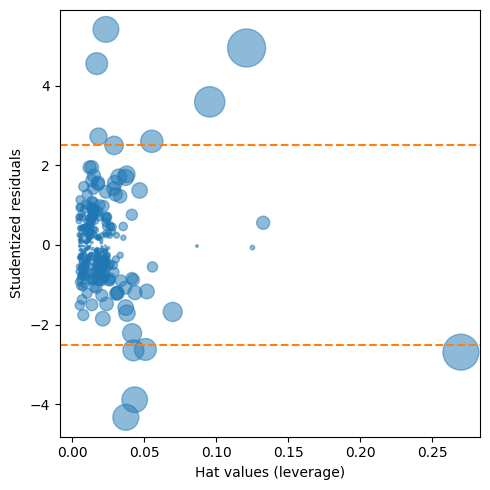

In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal,
           s=1000 * np.sqrt(influence.cooks_distance[0]), alpha=0.5)
ax.set_xlabel('Hat values (leverage)')
ax.set_ylabel('Studentized residuals')
plt.tight_layout(); plt.show()

In [32]:
# Bandingkan koefisien dengan dan tanpa record influential
mask = [dist < 0.08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]
ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1)).fit()

pd.DataFrame({'Original': result_98105.params, 'Influential removed': ols_infl.params}).round(2)

,Original,Influential removed
SqFtTotLiving,209.60,230.05
SqFtLot,38.93,33.14
Bathrooms,2282.26,-16131.88
Bedrooms,-26320.27,-22887.87
BldgGrade,130000.10,114870.56
const,-772549.86,-647137.10


Tanpa record influential, koefisien `Bathrooms` berubah cukup banyak. Pada data besar, satu record jarang bisa mengubah model secara drastis; tapi analisis ini tetap berguna untuk **mendeteksi anomali**.

### Heteroskedasticity, Non-Normality, dan Correlated Errors
Asumsi klasik regresi: residual (1) punya varians konstan, (2) berdistribusi normal, dan (3) saling independen. Dalam data science, asumsi ini lebih penting untuk **inferensi** (confidence interval, p-value) daripada untuk akurasi prediksi.

**Heteroskedastisitas**: varians residual tidak konstan. Cara mengecek: plot |residual| terhadap nilai prediksi.

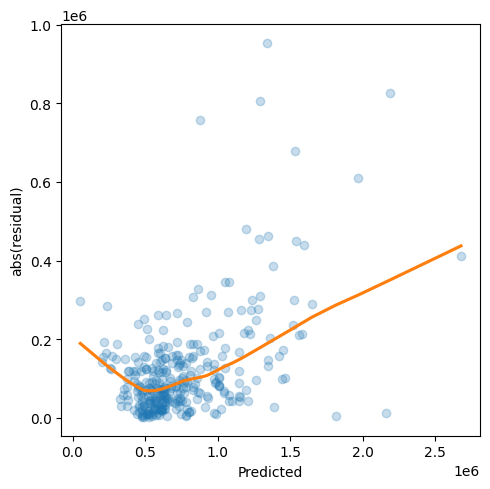

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid),
            scatter_kws={'alpha': 0.25}, line_kws={'color': 'C1'}, lowess=True, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('abs(residual)')
plt.tight_layout(); plt.show()

Varians residual cenderung **membesar** untuk rumah berharga tinggi, tapi juga besar untuk rumah murah. Ini menunjukkan model kita **belum menangkap** sesuatu yang penting (dalam buku, misalnya efek non-linear atau variabel yang hilang).

**Distribusi residual:** cek dengan histogram. Residual model ini ekornya lebih panjang dari normal dan sedikit miring ke kanan.

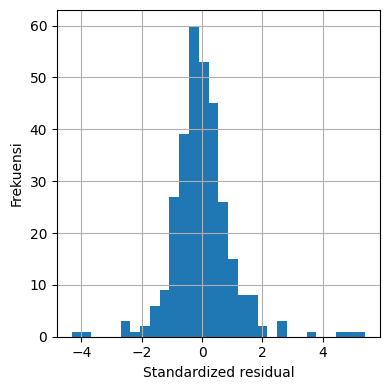

In [34]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax, bins=30)
ax.set_xlabel('Standardized residual'); ax.set_ylabel('Frekuensi')
plt.tight_layout(); plt.show()

**Correlated errors (autokorelasi):** relevan terutama untuk data yang dikumpulkan dari waktu ke waktu (time series). Bisa diuji dengan statistik **Durbin-Watson** (nilai ≈ 2 berarti tidak ada autokorelasi). Untuk regresi biasa dalam data science, ini jarang menjadi masalah kecuali datanya berurutan waktu.

In [35]:
from statsmodels.stats.stattools import durbin_watson
print('Durbin-Watson:', round(durbin_watson(result_98105.resid), 3))

Durbin-Watson: 1.508


### Partial Residual Plots dan Non-linearitas
**Partial residual plot** memperlihatkan hubungan antara **satu prediktor** dan outcome, setelah efek prediktor lain diperhitungkan:

**Partial residual = residual + $\hat{b}_i X_i$**

Garis regresi yang diestimasi (linear) digambar bersama, bersama kurva halus (lowess) dari partial residual. Jika kurva halus menyimpang dari garis lurus, berarti hubungannya **tidak linear**.

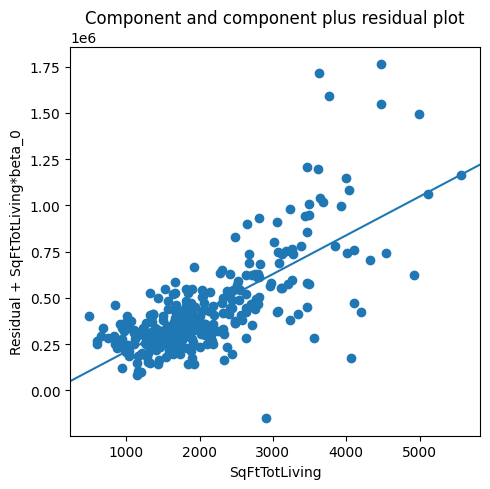

In [36]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)
plt.tight_layout(); plt.show()

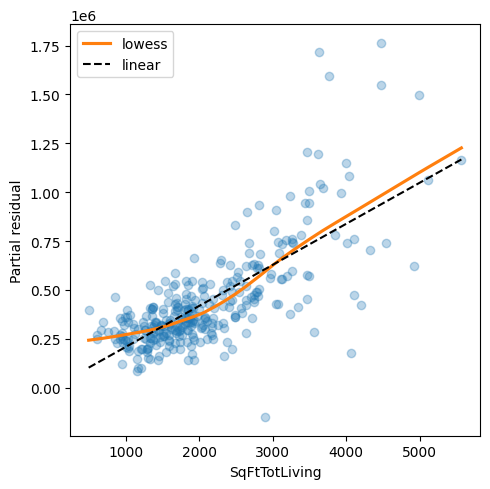

In [37]:
# Versi manual, dengan lowess untuk melihat non-linearitas
pr = result_98105.resid + result_98105.params['SqFtTotLiving'] * house_98105['SqFtTotLiving']
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=house_98105['SqFtTotLiving'], y=pr, lowess=True, scatter_kws={'alpha': 0.3},
            line_kws={'color': 'C1', 'label': 'lowess'}, ax=ax)
x_line = np.linspace(house_98105['SqFtTotLiving'].min(), house_98105['SqFtTotLiving'].max(), 100)
ax.plot(x_line, result_98105.params['SqFtTotLiving'] * x_line, color='black', ls='--', label='linear')
ax.set_xlabel('SqFtTotLiving'); ax.set_ylabel('Partial residual'); ax.legend()
plt.tight_layout(); plt.show()

Kurva lowess menunjukkan bahwa model linear **meremehkan** harga rumah kecil (< 1.000 sq ft) dan **melebih-lebihkan** harga rumah di tengah rentang (2.000–3.000 sq ft). Artinya hubungan luas bangunan dan harga **tidak sepenuhnya linear**: tambahan 500 sq ft pada rumah kecil lebih berarti daripada pada rumah besar. Solusinya: model non-linear (bagian berikutnya).

## 11. Regresi Polinomial dan Spline

Hubungan antara outcome dan prediktor tidak selalu linear. Contoh: respons obat terhadap dosis sering non-linear; permintaan produk tidak linear terhadap belanja iklan (ada titik jenuh).

**Istilah kunci:**
- **Polynomial regression** — menambahkan suku pangkat (kuadrat, kubik) ke regresi.
- **Spline regression** — mencocokkan kurva halus dengan serangkaian segmen polinomial.
- **Knots** — titik-titik yang memisahkan segmen spline.
- **Generalized additive models (GAM)** — model spline dengan pemilihan knot otomatis.

**Catatan:** regresi polinomial/spline masih merupakan **model linear** dalam parameternya (koefisien masuk secara linear). Yang non-linear adalah hubungannya terhadap X. Berbeda dengan *nonlinear regression* sejati yang membutuhkan optimasi numerik.

### Polynomial Regression
$$Y = b_0 + b_1 X + b_2 X^2 + e$$

In [38]:
model_poly = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving + np.power(SqFtTotLiving, 2) + '
                     'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary().tables[1])

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                  -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving                  7.4521     55.418      0.134      0.893    -101.597     116.501
np.power(SqFtTotLiving, 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                       32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms                  -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms                   -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade                   1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05


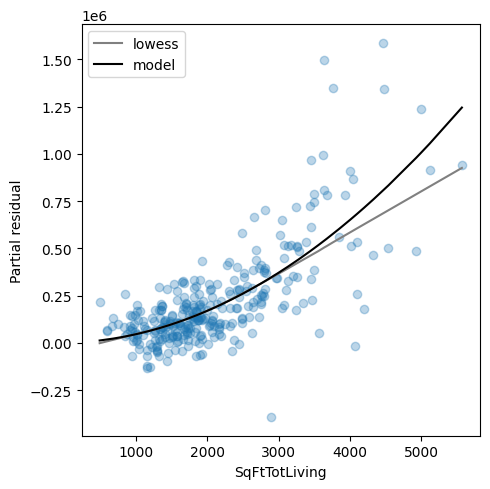

In [39]:
# Partial residual plot untuk suku polinomial
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    copy_df = df.copy()
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df[c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)
    ax.scatter(results.feature, results.ypartial + results.residual, alpha=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray', label='lowess')
    ax.plot(results.feature, results.ypartial, color='black', label='model')
    ax.legend()
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)
ax.set_xlabel('SqFtTotLiving'); ax.set_ylabel('Partial residual')
plt.tight_layout(); plt.show()

Kurva model polinomial (hitam) sekarang lebih mengikuti kurva lowess (abu-abu).

### Splines
Polinomial punya kelemahan: kurvanya bisa "liar" di ujung-ujung, dan tidak fleksibel secara lokal. **Spline** menyelesaikan ini dengan cara membagi rentang X menjadi beberapa segmen (dipisah oleh **knots**), lalu mencocokkan polinomial (biasanya kubik) di tiap segmen, dengan syarat kurvanya menyambung dengan halus di setiap knot.

Istilah "spline" berasal dari alat gambar para perancang kapal: batang kayu tipis yang dilenturkan dengan pemberat untuk menggambar kurva halus.

Di statsmodels, kita bisa memakai **B-spline** dengan fungsi `bs()` dari *patsy* dalam formula.

In [40]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + '
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary().tables[1])

                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                            -4.142e+05   1.43e+05     -2.899      0.004   -6.95e+05   -1.33e+05
bs(SqFtTotLiving, df=6, degree=3)[0] -1.995e+05   1.86e+05     -1.076      0.283   -5.65e+05    1.66e+05
bs(SqFtTotLiving, df=6, degree=3)[1] -1.206e+05   1.23e+05     -0.983      0.326   -3.62e+05    1.21e+05
bs(SqFtTotLiving, df=6, degree=3)[2] -7.164e+04   1.36e+05     -0.525      0.600    -3.4e+05    1.97e+05
bs(SqFtTotLiving, df=6, degree=3)[3]  1.957e+05   1.62e+05      1.212      0.227   -1.22e+05    5.14e+05
bs(SqFtTotLiving, df=6, degree=3)[4]  8.452e+05   2.18e+05      3.878      0.000    4.16e+05    1.27e+06
bs(SqFtTotLiving, df=6, degree=3)[5]  6.955e+05   2.14e+05      3.255      0.001    2.75e+05    1.12e+06
SqFtLot                                 33.3258      5.

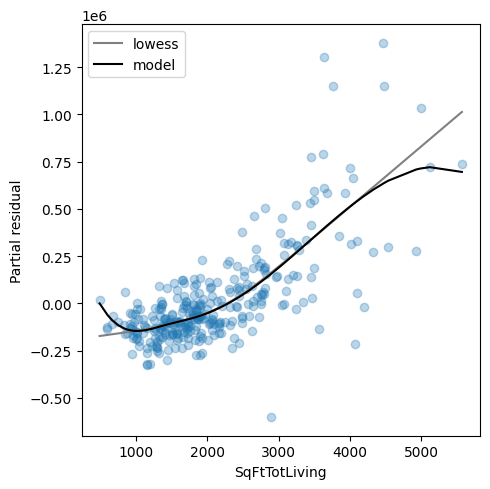

In [41]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)
ax.set_xlabel('SqFtTotLiving'); ax.set_ylabel('Partial residual')
plt.tight_layout(); plt.show()

Berbeda dengan polinomial, koefisien spline **tidak punya interpretasi langsung**. Evaluasi dilakukan secara visual (partial residual plot). Spline lebih mengikuti bentuk kurva lowess, walau terlihat sedikit "bergelombang" di rentang besar. Apakah itu nyata (rumah besar punya pola harga khusus) atau overfitting, perlu dipikirkan dengan pengetahuan domain dan divalidasi.

### Generalized Additive Models (GAM)
Masalah spline: kita harus menentukan **jumlah dan lokasi knot** sendiri. **GAM** menentukan kehalusan kurva secara otomatis. Di Python, GAM tersedia lewat paket `pygam`. Setiap prediktor bisa diberi fungsi:
- `s(i)` — spline smoothing (non-linear) untuk variabel ke-i,
- `l(i)` — suku linear.

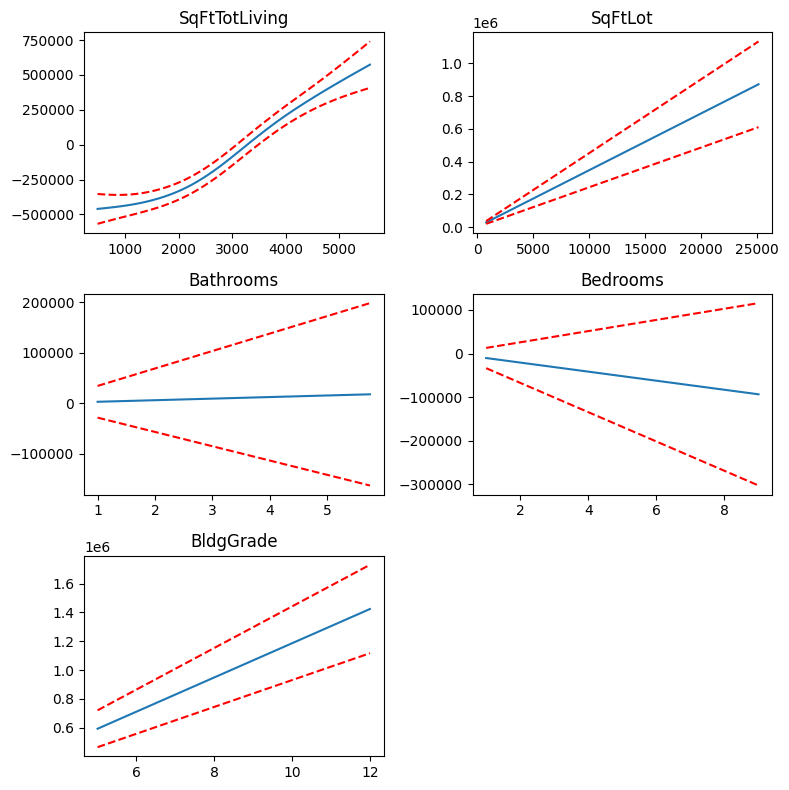

In [42]:
try:
    from pygam import LinearGAM, s, l
    predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
    X = house_98105[predictors].values
    y = house_98105[outcome]
    gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
    gam.gridsearch(X, y, progress=False)

    fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)
    for i, title in enumerate(predictors):
        ax = axes[i // 2, i % 2]
        XX = gam.generate_X_grid(term=i)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
        ax.set_title(title)
    axes[2][1].set_visible(False)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('pygam tidak bisa dijalankan di environment ini:', type(e).__name__, e)
    print('Alternatif: gunakan spline di atas, atau install versi pygam yang kompatibel.')

Plot pertama memperlihatkan efek `SqFtTotLiving` yang dipelajari secara otomatis oleh GAM (non-linear), sedangkan prediktor lain dimodelkan linear. Garis merah putus-putus adalah interval kepercayaan 95%.

## Ringkasan Bab 4

- **Regresi linear** memodelkan hubungan antara outcome (Y) dan satu atau lebih prediktor (X) dengan persamaan linear. Koefisien diestimasi dengan **least squares**.
- Regresi dipakai untuk **prediksi** dan **penjelasan**, tapi **tidak membuktikan kausalitas**.
- **Multiple regression**: koefisien = efek satu prediktor dengan prediktor lain tetap.
- Metrik model: **RMSE/RSE** (akurasi), **R²** (variansi yang dijelaskan), **t-statistic & p-value** (panduan pentingnya variabel).
- **Cross-validation** menguji model di data yang tidak dipakai untuk melatih, mencegah overfitting.
- Pemilihan model: **AIC, BIC, adjusted R²**; **stepwise regression**; atau **penalized regression** (Ridge/Lasso). Pilih model paling sederhana yang cukup baik (Occam's razor).
- **Weighted regression** untuk record dengan keandalan berbeda atau data agregat.
- **Prediction interval** (nilai individual) selalu lebih lebar daripada **confidence interval** (rata-rata/koefisien). Hindari **ekstrapolasi**.
- **Variabel faktor**: gunakan **reference coding** ($P-1$ dummy). Faktor dengan banyak level bisa dikelompokkan (misalnya berdasarkan residual). Faktor ordinal bisa dipakai sebagai numerik.
- Hati-hati dengan **prediktor yang berkorelasi**, **multikolinearitas**, dan **confounding variable**. **Interaksi** menangkap efek yang saling bergantung.
- **Diagnostik**: outlier (standardized residual), influential value (hat-value, Cook's distance), heteroskedastisitas, dan **partial residual plot** untuk mendeteksi non-linearitas.
- Hubungan non-linear bisa ditangani dengan **polinomial**, **spline**, atau **GAM**.

Pesan utama: regresi adalah alat dasar yang sangat kuat, tetapi model yang baik butuh **pemilihan variabel yang cermat, validasi di data baru, dan pemeriksaan diagnostik**, bukan sekadar menjalankan `fit()`.